# Data Science & AI/ML Practical Exam — Set C
## Late Delivery Prediction and Operational Segments

**Student-level notebook:** each task is written in small, separate steps so the work is easy to read and explain.

This notebook follows the uploaded exam brief. Run cells from top to bottom. The supplied generator is kept unchanged. It creates the required Set C delivery dataset; it is not the campaign-response dataset from the original notebook.

## 1. Imports and folders

In [92]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data/raw")
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = Path("models")

for folder in [DATA_DIR, OUT_DIR, FIG_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders are ready.")

Folders are ready.


In [124]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)


## 2. Generate and load the data

### 2.1 Supplied data generator (unchanged)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
 df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)

In [94]:
data_path = DATA_DIR / "set_b.csv"
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (305, 7)


,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


## Module 1 — Maths and Advanced Statistics

### 1.1 Audit and split records first

In [95]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isna().sum())
print("Target counts:")
print(df["late"].value_counts())

Exact duplicate rows: 5
Missing values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64
Target counts:
late
0    156
1    149
Name: count, dtype: int64


In [96]:
clean_df = df.drop_duplicates().copy()
print("Clean shape:", clean_df.shape)
print("Unique records:", clean_df["record_id"].nunique())

Clean shape: (300, 7)
Unique records: 300


In [97]:
train_df, test_df = train_test_split(
    clean_df, test_size=0.20, random_state=RANDOM_STATE,
    stratify=clean_df["late"]
)
fit_df, val_df = train_test_split(
    train_df, test_size=0.20, random_state=RANDOM_STATE,
    stratify=train_df["late"]
)

print("Fit:", fit_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Fit: (192, 7)
Validation: (48, 7)
Test: (60, 7)


In [98]:
fit_ids = set(fit_df.record_id)
val_ids = set(val_df.record_id)
test_ids = set(test_df.record_id)

print("Partitions disjoint:",
      fit_ids.isdisjoint(val_ids) and fit_ids.isdisjoint(test_ids)
      and val_ids.isdisjoint(test_ids))

split_rows = pd.concat([
    pd.DataFrame({"record_id": fit_df.record_id, "partition": "fit"}),
    pd.DataFrame({"record_id": val_df.record_id, "partition": "validation"}),
    pd.DataFrame({"record_id": test_df.record_id, "partition": "test"})
])
split_rows.to_csv(OUT_DIR / "splits.csv", index=False)

Partitions disjoint: True


### 1.2 Descriptive statistics for distance

In [99]:
distance_values = fit_df["distance"].dropna()
distance_summary = pd.DataFrame({
    "n": [distance_values.count()],
    "mean": [distance_values.mean()],
    "median": [distance_values.median()],
    "sample_std": [distance_values.std(ddof=1)]
})
display(distance_summary)
distance_summary.to_csv(OUT_DIR / "distance_summary.csv", index=False)

,n,mean,median,sample_std
0,184,49.744402,50.2,10.835872


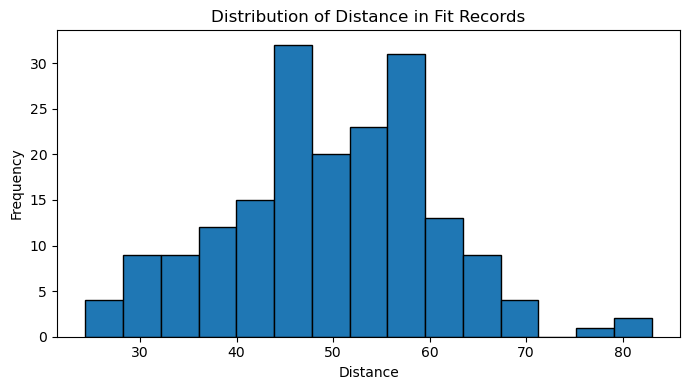

In [100]:
plt.figure(figsize=(7, 4))
plt.hist(distance_values, bins=15, edgecolor="black")
plt.title("Distribution of Distance in Fit Records")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "distance_histogram.png")
plt.show()

### 1.3 Welch t-test and confidence interval

In [101]:
g1 = fit_df.loc[fit_df.group == "G1", "distance"].dropna()
g2 = fit_df.loc[fit_df.group == "G2", "distance"].dropna()

# H0: the mean distance is equal for G1 and G2.
# H1: the mean distance is different for G1 and G2.
t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)
print("H0: mean distance in G1 = mean distance in G2")
print("H1: mean distance in G1 is not equal to mean distance in G2")
print("G1 count:", len(g1), " G2 count:", len(g2))
print("Welch t statistic:", t_stat)
print("p-value:", p_value)

H0: mean distance in G1 = mean distance in G2
H1: mean distance in G1 is not equal to mean distance in G2
G1 count: 104  G2 count: 80
Welch t statistic: 0.7061612423464614
p-value: 0.48105881393425987


In [102]:
n_obs = len(distance_values)
mean_obs = distance_values.mean()
se = stats.sem(distance_values)
critical_t = stats.t.ppf(0.975, df=n_obs - 1)
ci_low = mean_obs - critical_t * se
ci_high = mean_obs + critical_t * se

print("95% confidence interval:", (ci_low, ci_high))
print("Assumptions: independent observations and approximately normal sampling distribution.")
if p_value < 0.05:
    print("At 0.05, the group means show a statistically significant difference.")
else:
    print("At 0.05, there is not enough evidence of a difference in group means.")
print("This is an association in synthetic data, not proof of causation.")

95% confidence interval: (np.float64(48.16829889365394), np.float64(51.320505454172164))
Assumptions: independent observations and approximately normal sampling distribution.
At 0.05, there is not enough evidence of a difference in group means.
This is an association in synthetic data, not proof of causation.


### 1.4 Covariance matrix and eigenvalues

In [103]:
complete_rows = fit_df[["distance", "traffic"]].dropna()
matrix = complete_rows.to_numpy()
column_means = matrix.mean(axis=0)
centered_matrix = matrix - column_means

cov_matrix = centered_matrix.T @ centered_matrix / (len(centered_matrix) - 1)
print("Number of complete rows:", len(complete_rows))
print("Centered matrix (first five rows):")
print(centered_matrix[:5])
print("Sample covariance matrix:")
print(cov_matrix)

Number of complete rows: 184
Centered matrix (first five rows):
[[  6.10559783  -6.78494565]
 [  2.00559783 -12.83494565]
 [  9.24559783  15.84505435]
 [  8.29559783   3.97505435]
 [  7.85559783 -11.74494565]]
Sample covariance matrix:
[[117.41612751  -1.23645741]
 [ -1.23645741 107.43358798]]


In [104]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
largest_index = np.argmax(eigenvalues)
variance_share = eigenvalues[largest_index] / eigenvalues.sum()

print("Eigenvalues:", eigenvalues)
print("Largest eigenvalue:", eigenvalues[largest_index])
print("Principal direction:", eigenvectors[:, largest_index])
print("Variance share:", variance_share)

Eigenvalues: [107.28271803 117.56699745]
Largest eigenvalue: 117.56699745404018
Principal direction: [-0.99263792  0.1211196 ]
Variance share: 0.5228692293455571


## Module 2 — Data Preprocessing and Feature Engineering

### 2.1 Separate predictors and target

In [105]:
numeric_columns = ["distance", "load", "traffic", "staff"]
categorical_columns = ["group"]

X_fit_raw = fit_df[numeric_columns + categorical_columns].copy()
X_val_raw = val_df[numeric_columns + categorical_columns].copy()
X_test_raw = test_df[numeric_columns + categorical_columns].copy()

y_fit = fit_df["late"]
y_val = val_df["late"]
y_test = test_df["late"]

### 2.2 Impute missing numeric values

In [106]:
imputer = SimpleImputer(strategy="median")
fit_numeric = pd.DataFrame(
    imputer.fit_transform(X_fit_raw[numeric_columns]),
    columns=numeric_columns, index=fit_df.index
)
val_numeric = pd.DataFrame(
    imputer.transform(X_val_raw[numeric_columns]),
    columns=numeric_columns, index=val_df.index
)
test_numeric = pd.DataFrame(
    imputer.transform(X_test_raw[numeric_columns]),
    columns=numeric_columns, index=test_df.index
)
print("Missing values after imputation:", fit_numeric.isna().sum().sum())

Missing values after imputation: 0


### 2.3 Create engineered feature before scaling

In [107]:
fit_numeric["engineered_feature"] = fit_numeric["load"] / (fit_numeric["staff"] + 1)
val_numeric["engineered_feature"] = val_numeric["load"] / (val_numeric["staff"] + 1)
test_numeric["engineered_feature"] = test_numeric["load"] / (test_numeric["staff"] + 1)

model_numeric_columns = numeric_columns + ["engineered_feature"]
print(fit_numeric[model_numeric_columns].head())

     distance    load  traffic  staff  engineered_feature
288     55.85  54.680    42.44  54.95            0.977301
73      51.75  47.550    36.39  36.13            1.280636
259     58.99  38.830    65.07  53.74            0.709353
280     58.04  37.760    53.20  53.97            0.686920
243     57.60  49.965    37.48  57.45            0.854833


### 2.4 Encode group and scale numeric columns

In [108]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
fit_group = encoder.fit_transform(X_fit_raw[["group"]])
val_group = encoder.transform(X_val_raw[["group"]])
test_group = encoder.transform(X_test_raw[["group"]])

scaler = StandardScaler()
fit_scaled = scaler.fit_transform(fit_numeric[model_numeric_columns])
val_scaled = scaler.transform(val_numeric[model_numeric_columns])
test_scaled = scaler.transform(test_numeric[model_numeric_columns])

feature_names = model_numeric_columns + encoder.get_feature_names_out(["group"]).tolist()
X_fit = np.column_stack([fit_scaled, fit_group])
X_val = np.column_stack([val_scaled, val_group])
X_test = np.column_stack([test_scaled, test_group])

print("Feature names:", feature_names)
print("Fit shape:", X_fit.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("All finite:", np.isfinite(X_fit).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all())

Feature names: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']
Fit shape: (192, 7)
Validation shape: (48, 7)
Test shape: (60, 7)
All finite: True


In [109]:
# The target and record_id are not predictors. Test data is transformed with
# fit-only preprocessing and is not used to calculate training statistics.
import joblib
joblib.dump({"imputer": imputer, "encoder": encoder, "scaler": scaler},
            MODEL_DIR / "preprocessing.joblib")

['models\\preprocessing.joblib']

## Module 3 — Supervised Learning

### 3.1 Baseline and logistic regression

In [110]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_fit, y_fit)

logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_fit, y_fit)

print("Target: late (1 = late, 0 = not late)")
print("Predictors:", feature_names)
print("Model: LogisticRegression(max_iter=1000, random_state=42)")

Target: late (1 = late, 0 = not late)
Predictors: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']
Model: LogisticRegression(max_iter=1000, random_state=42)


### 3.2 Test predictions and metrics

In [111]:
baseline_pred = baseline.predict(X_test)
logistic_probability = logistic_model.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_probability >= 0.5).astype(int)

def get_metrics(actual, predicted):
    return {
        "accuracy": accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0)
    }

baseline_metrics = get_metrics(y_test, baseline_pred)
logistic_metrics = get_metrics(y_test, logistic_pred)
print("Baseline:", baseline_metrics)
print("Logistic regression:", logistic_metrics)

Baseline: {'accuracy': 0.5166666666666667, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
Logistic regression: {'accuracy': 0.85, 'precision': 0.8846153846153846, 'recall': 0.7931034482758621, 'f1': 0.8363636363636363}


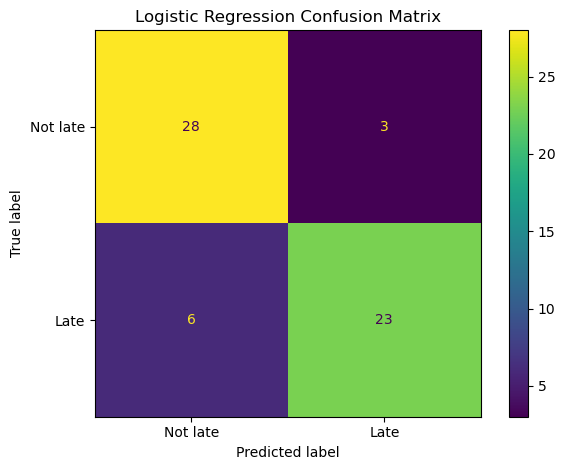

In [112]:
cm = confusion_matrix(y_test, logistic_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not late", "Late"]).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "logistic_confusion_matrix.png")
plt.show()

test_predictions = pd.DataFrame({
    "record_id": test_df.record_id.values,
    "true_label": y_test.values,
    "predicted_label": logistic_pred,
    "class_1_probability": logistic_probability
})
test_predictions.to_csv(OUT_DIR / "logistic_test_predictions.csv", index=False)

### 3.3 Simple interpretation

In [113]:
print("False positive: the model predicts late when the delivery is not late.")
print("False negative: the model predicts not late when the delivery is late.")
print("Compare logistic F1 with baseline accuracy carefully; the baseline predicts only the majority class.")
print("A single small test set gives limited evidence about future performance.")

False positive: the model predicts late when the delivery is not late.
False negative: the model predicts not late when the delivery is late.
Compare logistic F1 with baseline accuracy carefully; the baseline predicts only the majority class.
A single small test set gives limited evidence about future performance.


## Module 4 — Unsupervised Learning

### 4.1 Try K-Means with k = 2, 3, 4

In [114]:
# Use numeric predictors only. Group one-hot columns, target and ID are excluded.
cluster_data = fit_scaled.copy()
cluster_scores = []

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    cluster_labels = kmeans.fit_predict(cluster_data)
    score = silhouette_score(cluster_data, cluster_labels)
    cluster_scores.append({"k": k, "inertia": kmeans.inertia_, "silhouette": score})

cluster_scores_df = pd.DataFrame(cluster_scores)
display(cluster_scores_df)
cluster_scores_df.to_csv(OUT_DIR / "k_selection_scores.csv", index=False)

,k,inertia,silhouette
0,2,719.632089,0.246337
1,3,599.659398,0.207147
2,4,535.383548,0.190232


In [115]:
best_k = int(cluster_scores_df.sort_values(
    ["silhouette", "k"], ascending=[False, True]
).iloc[0]["k"])
print("Selected k:", best_k, "because it has the highest silhouette score.")

Selected k: 2 because it has the highest silhouette score.


### 4.2 Describe the segments

In [116]:
final_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
fit_clusters = final_kmeans.fit_predict(cluster_data)

cluster_profile = fit_numeric[model_numeric_columns].copy()
cluster_profile["cluster"] = fit_clusters
cluster_profile = cluster_profile.groupby("cluster").mean()
display(cluster_profile)
cluster_profile.to_csv(OUT_DIR / "cluster_profiles.csv")
print("Cluster numbers are arbitrary labels. They are not the late/not-late target classes.")

,distance,load,traffic,staff,engineered_feature
cluster,,,,,
0,48.418955,47.127985,49.066269,54.035000,0.863256
1,52.869483,57.461552,49.856207,41.426724,1.372952


Cluster numbers are arbitrary labels. They are not the late/not-late target classes.


## Module 5 — Artificial Neural Network (ANN)

### 5.1 Build the network

In [117]:
import tensorflow as tf
tf.keras.utils.set_random_seed(RANDOM_STATE)

ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_fit.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
ann_model.summary()
print("Trainable parameters:", ann_model.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 273


A sigmoid output gives a probability between 0 and 1 for the two classes. Binary cross-entropy is used because the target has two classes.

### 5.2 Train with validation and early stopping

In [118]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = ann_model.fit(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

actual_epochs = len(history.history["loss"])
print("Random seed:", RANDOM_STATE)
print("Actual epochs:", actual_epochs)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5156 - loss: 0.7597 - val_accuracy: 0.4792 - val_loss: 0.7247
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5417 - loss: 0.7331 - val_accuracy: 0.5208 - val_loss: 0.7070
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5521 - loss: 0.7116 - val_accuracy: 0.5208 - val_loss: 0.6924
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 0.6938 - val_accuracy: 0.5417 - val_loss: 0.6797
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6042 - loss: 0.6787 - val_accuracy: 0.5625 - val_loss: 0.6692
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 0.6655 - val_accuracy: 0.6042 - val_loss: 0.6600
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6354 - loss: 0.6538 - val_accuracy: 0.6042 - val_loss: 0.6510
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6562 - loss: 0.6426 - val_accuracy: 0.6250 - val_loss

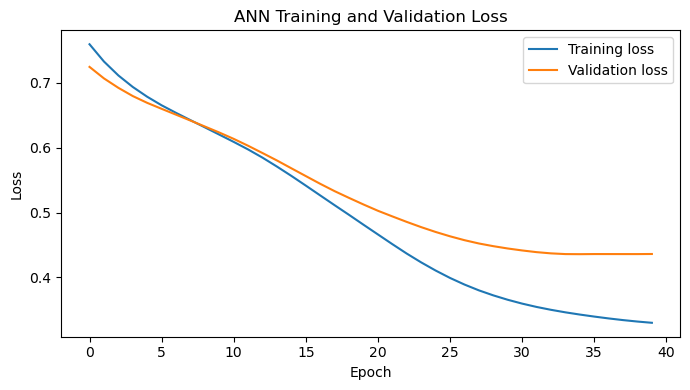

If training loss keeps falling while validation loss rises, this can indicate overfitting.


In [119]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ann_loss_curve.png")
plt.show()
print("If training loss keeps falling while validation loss rises, this can indicate overfitting.")

### 5.3 Evaluate ANN on the same test records

In [120]:
ann_probability = ann_model.predict(X_test, verbose=0).ravel()
ann_pred = (ann_probability >= 0.5).astype(int)
ann_metrics = get_metrics(y_test, ann_pred)

print("ANN metrics:", ann_metrics)
print("Logistic regression F1:", logistic_metrics["f1"])
print("ANN F1:", ann_metrics["f1"])

ANN metrics: {'accuracy': 0.8333333333333334, 'precision': 0.8518518518518519, 'recall': 0.7931034482758621, 'f1': 0.8214285714285714}
Logistic regression F1: 0.8363636363636363
ANN F1: 0.8214285714285714


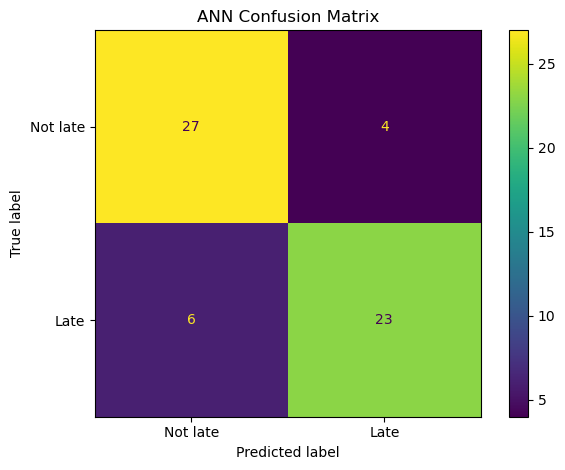

In [121]:
ann_cm = confusion_matrix(y_test, ann_pred)
ConfusionMatrixDisplay(ann_cm, display_labels=["Not late", "Late"]).plot()
plt.title("ANN Confusion Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "ann_confusion_matrix.png")
plt.show()

ann_predictions = pd.DataFrame({
    "record_id": test_df.record_id.values,
    "true_label": y_test.values,
    "predicted_label": ann_pred,
    "class_1_probability": ann_probability
})
ann_predictions.to_csv(OUT_DIR / "ann_test_predictions.csv", index=False)
ann_model.save(MODEL_DIR / "late_delivery_ann.keras")

## 6. Save comparison and package versions

In [122]:
comparison = pd.DataFrame([
    {"model": "Majority baseline", **baseline_metrics},
    {"model": "Logistic regression", **logistic_metrics},
    {"model": "ANN", **ann_metrics}
])
display(comparison)
comparison.to_csv(OUT_DIR / "model_comparison.csv", index=False)

,model,accuracy,precision,recall,f1
0,Majority baseline,0.516667,0.000000,0.000000,0.000000
1,Logistic regression,0.850000,0.884615,0.793103,0.836364
2,ANN,0.833333,0.851852,0.793103,0.821429


In [123]:
import sklearn
versions = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit_learn": sklearn.__version__,
    "tensorflow": tf.__version__
}
print(versions)
pd.Series(versions).to_csv(OUT_DIR / "library_versions.csv")
print("Saved outputs in:", OUT_DIR.resolve())
print("Saved models in:", MODEL_DIR.resolve())

{'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.15.3', 'scikit_learn': '1.6.1', 'tensorflow': '2.21.0'}
Saved outputs in: C:\Users\ASUS\Downloads\outputs
Saved models in: C:\Users\ASUS\Downloads\models


## 7. Final student notes

- The dataset is synthetic and contains 300 unique records after removing duplicates.
- The fit, validation and test partitions are kept separate.
- Imputation, encoding and scaling are fitted using fit records only.
- The test set is used only for the final evaluation.
- A false negative may mean a late delivery is not flagged; a false positive may cause unnecessary follow-up.
- Results from one small holdout should not be treated as proof of real-world performance.

**Before submission:** run the notebook from a clean kernel, check that every cell works, and explain the outputs in your own words.